# Convolutional autoencoder on MNIST

This notebook builds a **convolutional autoencoder** for handwritten digits from the MNIST dataset.

Compared to the fully connected autoencoder, this model uses convolutional layers that are better matched to image structure.


## What this notebook will do

We will go step by step:

1. load the MNIST dataset
2. display a few example digits
3. define a convolutional encoder and decoder
4. train the model
5. compare original and reconstructed images
6. visualize the latent representation
7. generate images from points in the latent space

This cleaned-up version removes some unnecessary complexity so the main ideas are easier to follow.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
from tqdm import tqdm
from sklearn.decomposition import PCA


In [2]:
# Define a local data directory and load the MNIST datasets.
data_dir = 'dataset'
train_dataset = torchvision.datasets.MNIST(data_dir, train=True, download=True)
test_dataset = torchvision.datasets.MNIST(data_dir, train=False, download=True)

print('Number of training images:', len(train_dataset))
print('Number of test images:', len(test_dataset))


Number of training images: 60000
Number of test images: 10000


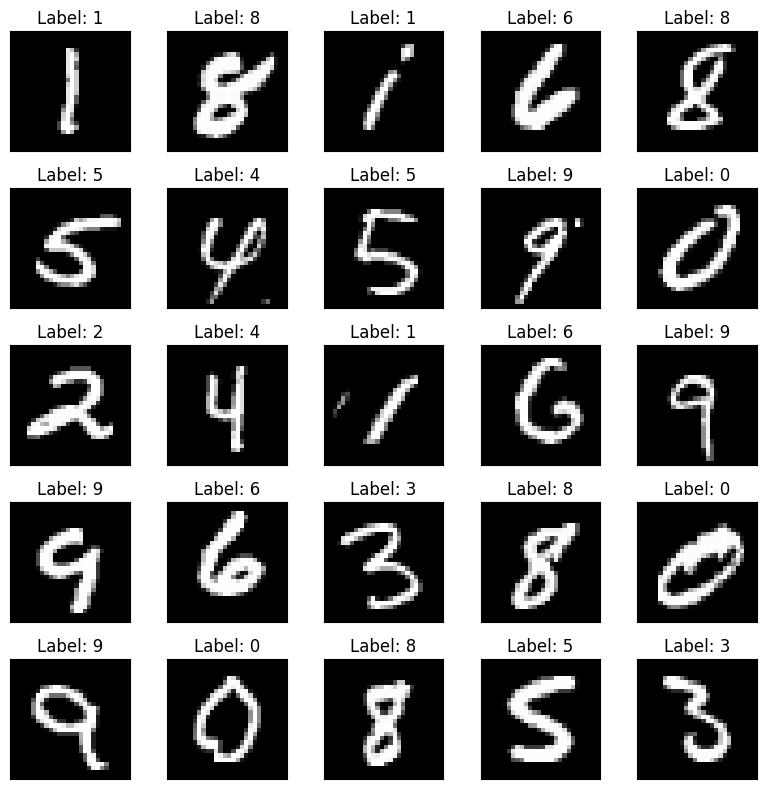

In [3]:
# Show a few random training images before any tensor conversion.
fig, axs = plt.subplots(5, 5, figsize=(8, 8))
for ax in axs.flatten():
    img, label = random.choice(train_dataset)
    ax.imshow(np.array(img), cmap='gist_gray')
    ax.set_title(f'Label: {label}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


In [4]:
# Convert the PIL images to tensors.
train_transform = transforms.Compose([transforms.ToTensor()])
test_transform = transforms.Compose([transforms.ToTensor()])
train_dataset.transform = train_transform
test_dataset.transform = test_transform


In [5]:
# Split the original training set into a training and validation part.
# We keep 80% for training and 20% for validation.
m = len(train_dataset)
train_data, val_data = random_split(train_dataset, [int(m - m * 0.2), int(m * 0.2)])

batch_size = 256

# Data loaders handle batching and (for the training sample) shuffling.
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


## Define the convolutional encoder and decoder

The encoder uses three convolutional layers to compress the image into a small latent vector.
The decoder uses transposed convolutions to reconstruct the image.


In [6]:
class Encoder(nn.Module):
    def __init__(self, encoded_space_dim):
        super().__init__()

        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )

        self.flatten = nn.Flatten(start_dim=1)

        self.encoder_lin = nn.Sequential(
            nn.Linear(3 * 3 * 32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )

    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x


class Decoder(nn.Module):
    def __init__(self, encoded_space_dim):
        super().__init__()

        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x


In [7]:
# Fix the random seed so the result is reproducible.
torch.manual_seed(0)

# Choose the latent-space dimension.
# A small dimension forces the autoencoder to compress the image strongly.
d = 4

encoder = Encoder(encoded_space_dim=d)
decoder = Decoder(encoded_space_dim=d)


In [8]:
# Check the shape changes through the autoencoder on one example image.
img, _ = test_dataset[0]
img = img.unsqueeze(0)
print('Original image shape:', img.shape)

img_enc = encoder(img)
print('Encoded image shape:', img_enc.shape)

dec_img = decoder(img_enc)
print('Decoded image shape:', dec_img.shape)


Original image shape: torch.Size([1, 1, 28, 28])
Encoded image shape: torch.Size([1, 4])
Decoded image shape: torch.Size([1, 1, 28, 28])


In [9]:
# # Define the loss function and optimizer.
# loss_fn = torch.nn.MSELoss()
# lr = 0.001

# params_to_optimize = [
#     {'params': encoder.parameters()},
#     {'params': decoder.parameters()},
# ]

# optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

# # Select GPU if available.
# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# print(f'Selected device: {device}')

# encoder.to(device)
# decoder.to(device)

# import os
# import torch

## Environment variables disabled for full power usage:
# os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Define the loss function and optimizer.
loss_fn = torch.nn.MSELoss()
lr = 0.001

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()},
]

optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

# Select Apple's Metal GPU if available, else fallback to CPU.
if torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Selected device: {device}')

# Move models to the selected device
encoder.to(device)
decoder.to(device)

Selected device: mps


Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=288, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 3, 3))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)

## Training and evaluation helper functions

We define one function for a training epoch, one for a validation/test epoch, and one plotting helper for reconstructions.


In [10]:
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    encoder.train()
    decoder.train()
    train_loss = []

    for image_batch, _ in dataloader:
        image_batch = image_batch.to(device)
        encoded_data = encoder(image_batch)
        decoded_data = decoder(encoded_data)
        loss = loss_fn(decoded_data, image_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.detach().cpu().item())

    return np.mean(train_loss)


def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        conc_out = []
        conc_label = []

        for image_batch, _ in dataloader:
            image_batch = image_batch.to(device)
            encoded_data = encoder(image_batch)
            decoded_data = decoder(encoded_data)
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())

        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label)
        val_loss = loss_fn(conc_out, conc_label)

    return val_loss.item()


def plot_ae_outputs(encoder, decoder, n=5):
    plt.figure(figsize=(10, 4.5))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = test_dataset[i][0].unsqueeze(0).to(device)
        encoder.eval()
        decoder.eval()
        with torch.no_grad():
            rec_img = decoder(encoder(img))
        plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == n // 2:
            ax.set_title('Original images')

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == n // 2:
            ax.set_title('Reconstructed images')
    plt.show()



EPOCH 1/30 	 train loss 0.123 	 val loss 0.066


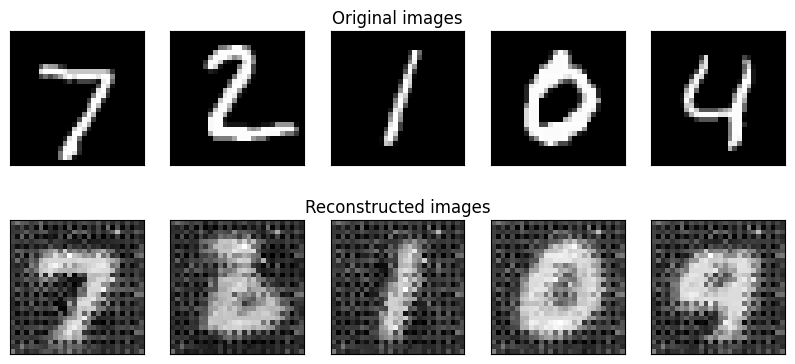


EPOCH 2/30 	 train loss 0.054 	 val loss 0.046


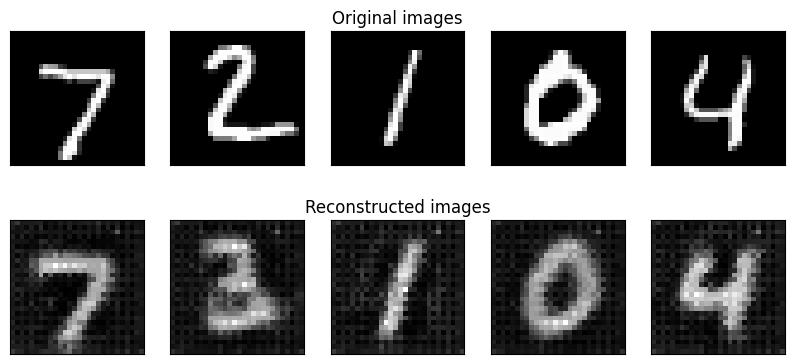


EPOCH 3/30 	 train loss 0.041 	 val loss 0.037


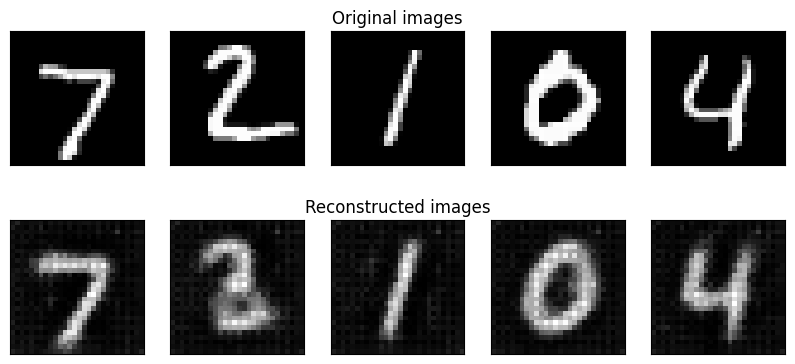


EPOCH 4/30 	 train loss 0.035 	 val loss 0.033


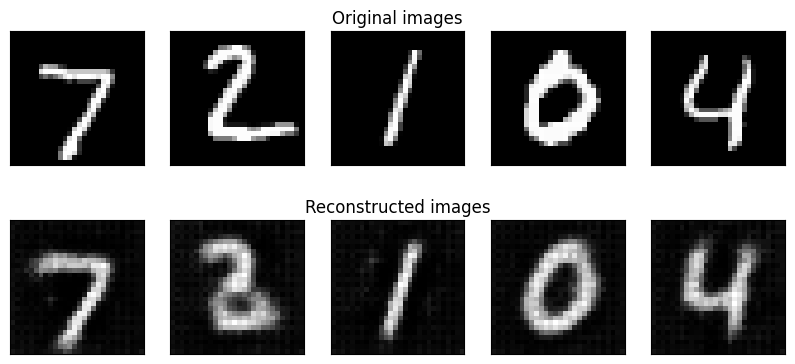


EPOCH 5/30 	 train loss 0.032 	 val loss 0.031


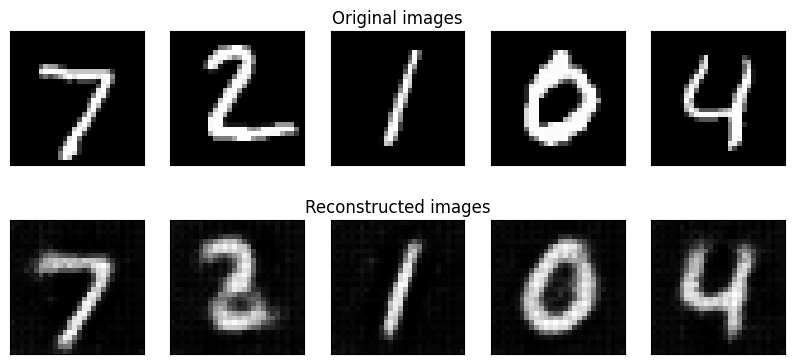


EPOCH 6/30 	 train loss 0.030 	 val loss 0.030


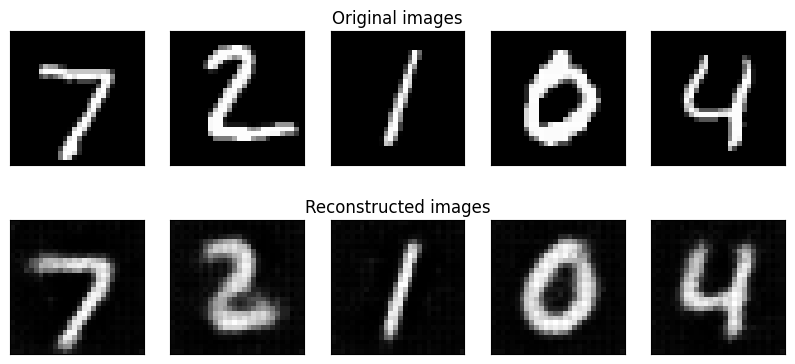


EPOCH 7/30 	 train loss 0.029 	 val loss 0.029


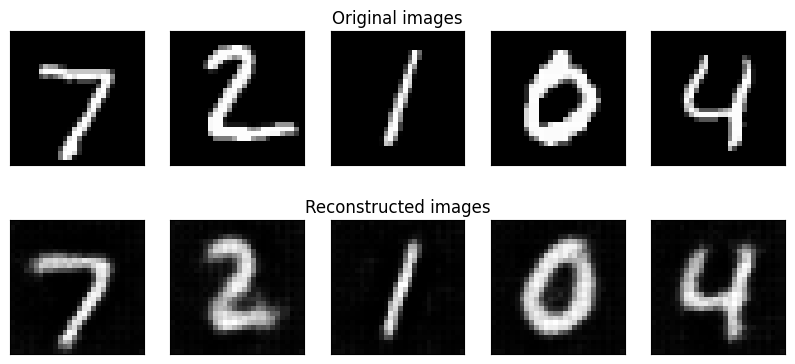


EPOCH 8/30 	 train loss 0.029 	 val loss 0.029


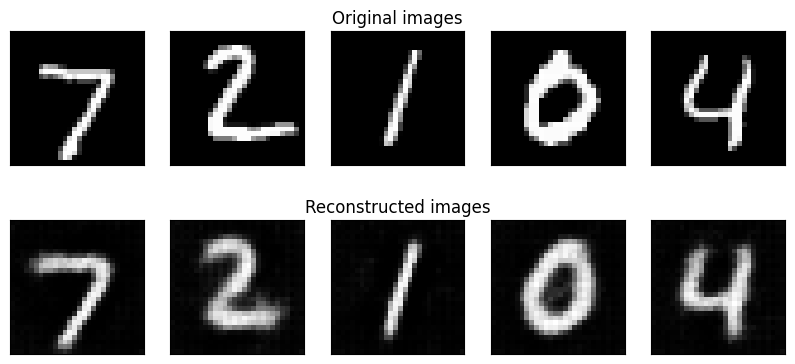


EPOCH 9/30 	 train loss 0.028 	 val loss 0.029


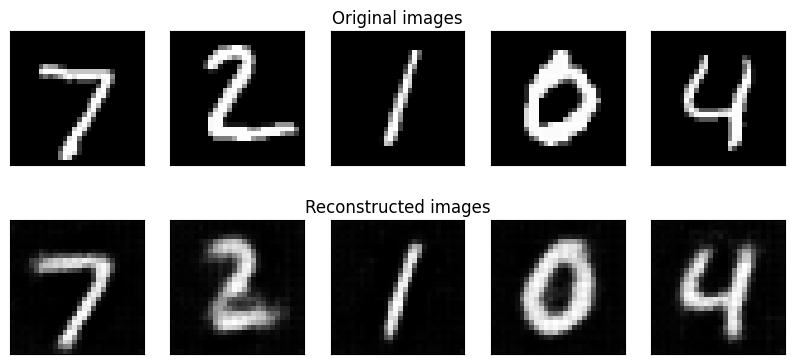


EPOCH 10/30 	 train loss 0.028 	 val loss 0.028


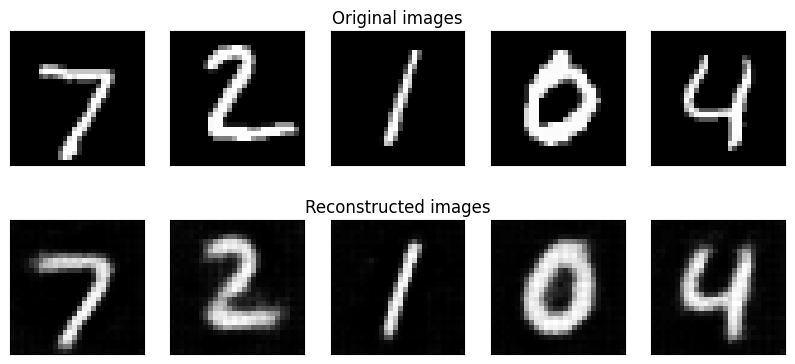


EPOCH 11/30 	 train loss 0.028 	 val loss 0.028


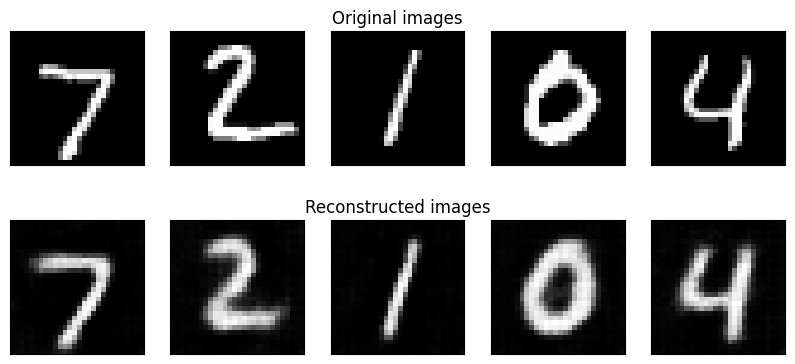


EPOCH 12/30 	 train loss 0.027 	 val loss 0.028


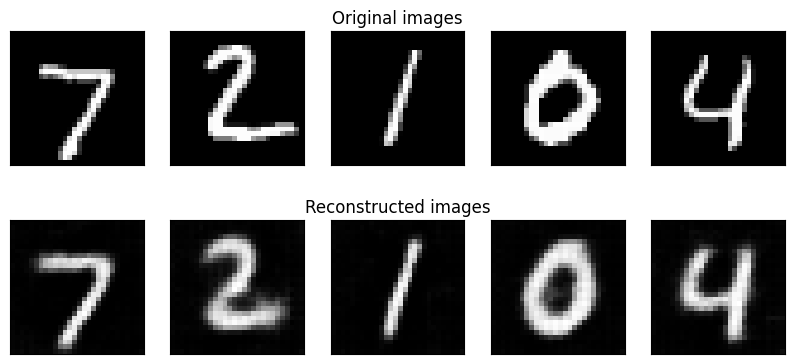


EPOCH 13/30 	 train loss 0.027 	 val loss 0.027


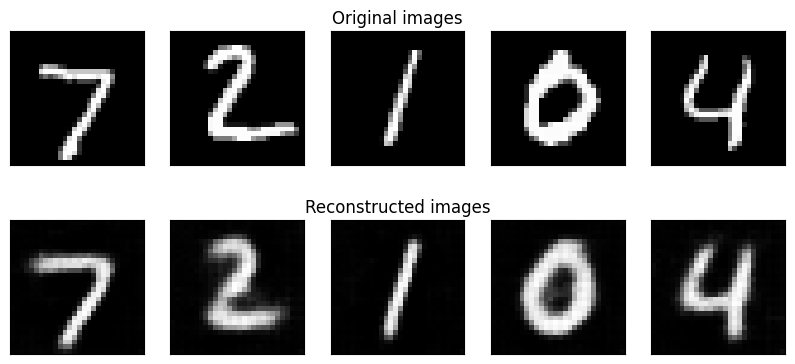


EPOCH 14/30 	 train loss 0.027 	 val loss 0.027


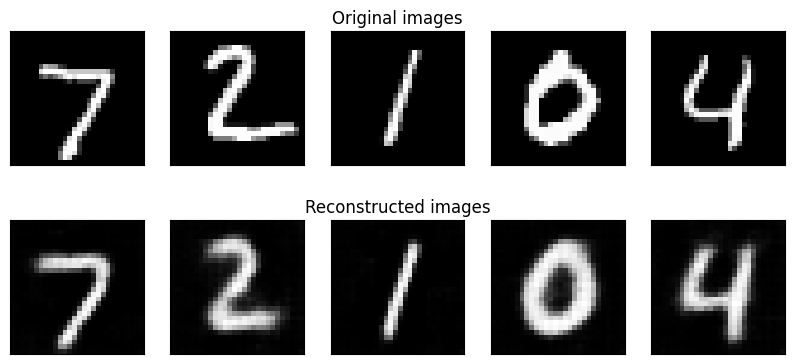


EPOCH 15/30 	 train loss 0.027 	 val loss 0.027


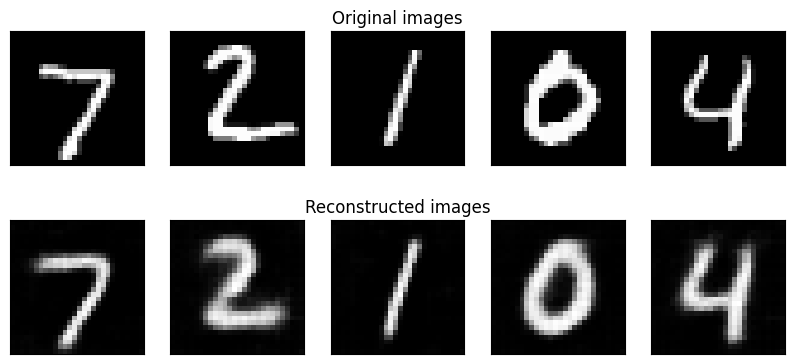


EPOCH 16/30 	 train loss 0.027 	 val loss 0.027


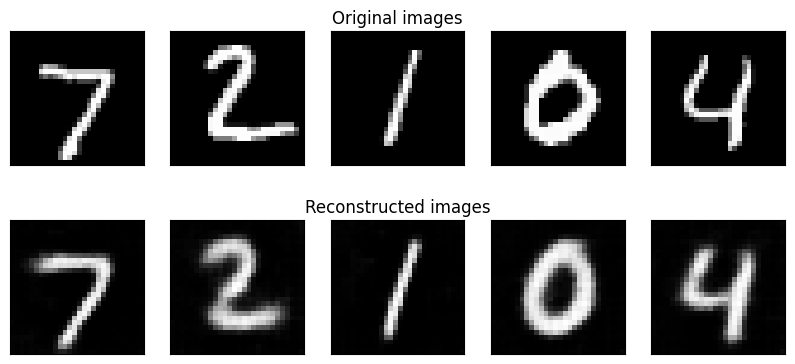


EPOCH 17/30 	 train loss 0.026 	 val loss 0.027


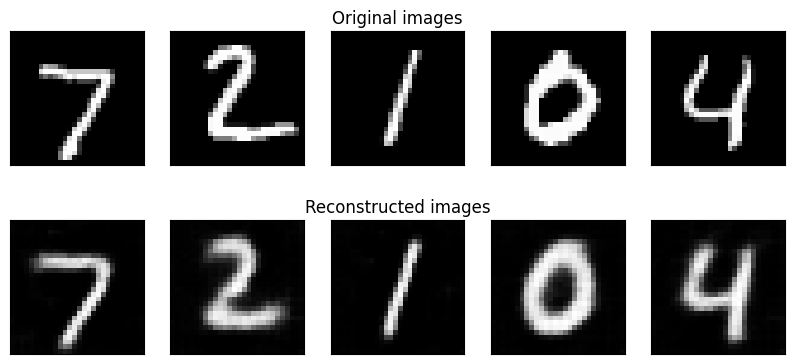


EPOCH 18/30 	 train loss 0.026 	 val loss 0.027


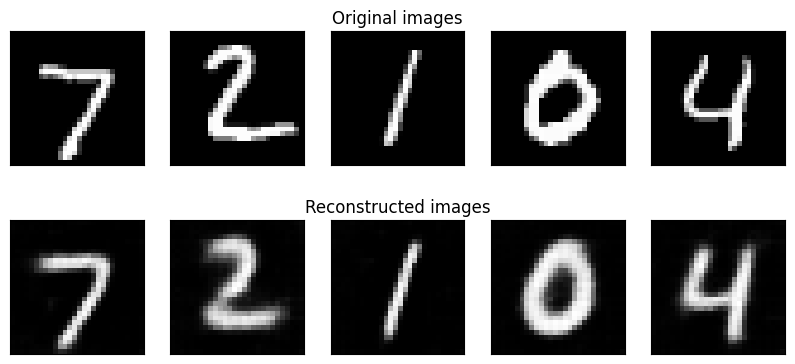


EPOCH 19/30 	 train loss 0.026 	 val loss 0.027


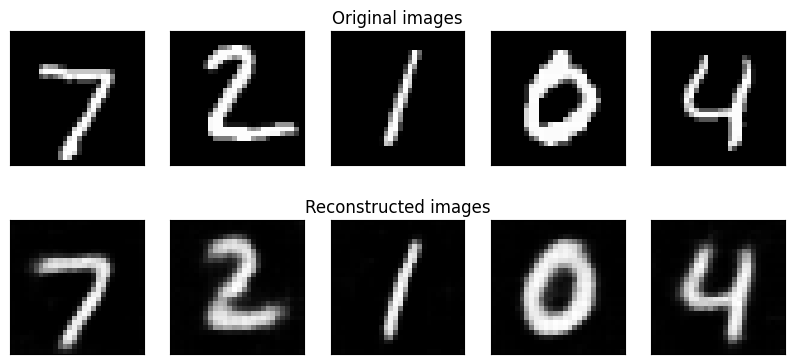


EPOCH 20/30 	 train loss 0.026 	 val loss 0.026


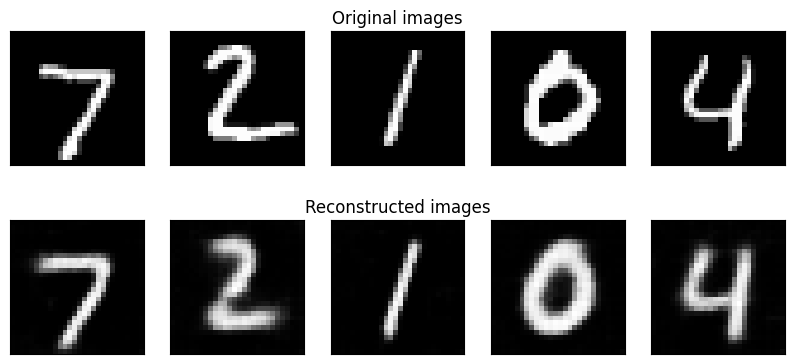


EPOCH 21/30 	 train loss 0.026 	 val loss 0.026


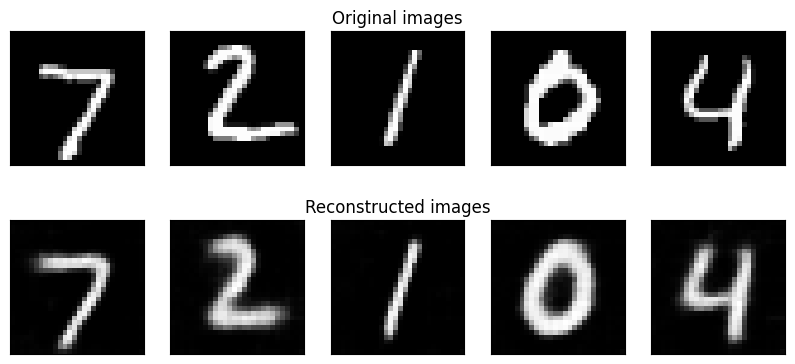


EPOCH 22/30 	 train loss 0.026 	 val loss 0.026


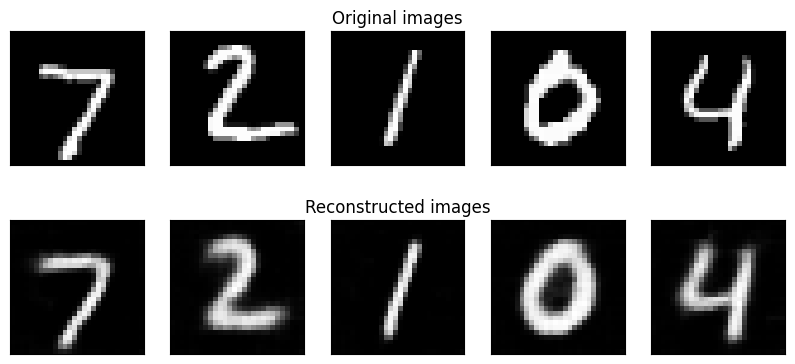


EPOCH 23/30 	 train loss 0.026 	 val loss 0.027


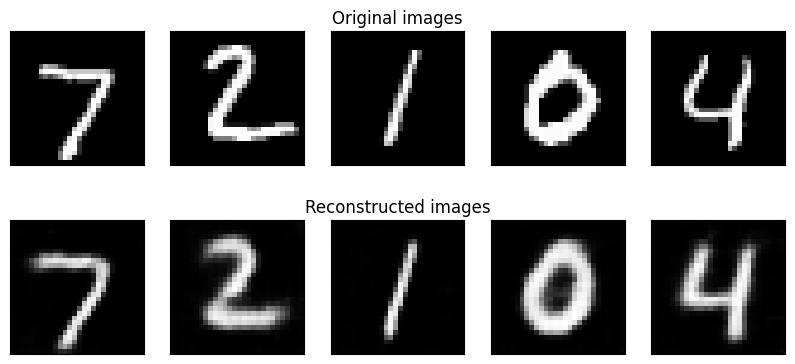


EPOCH 24/30 	 train loss 0.026 	 val loss 0.026


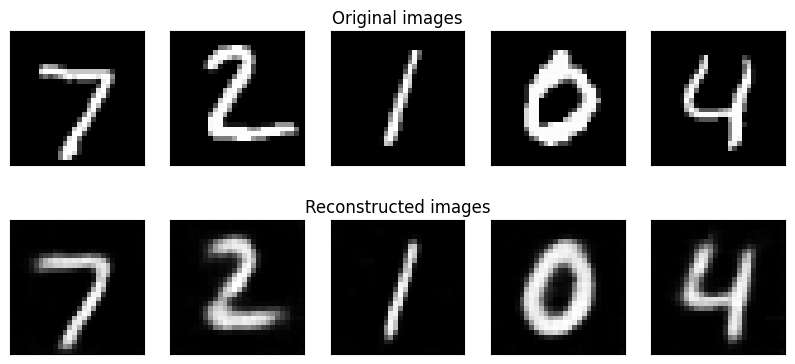


EPOCH 25/30 	 train loss 0.026 	 val loss 0.026


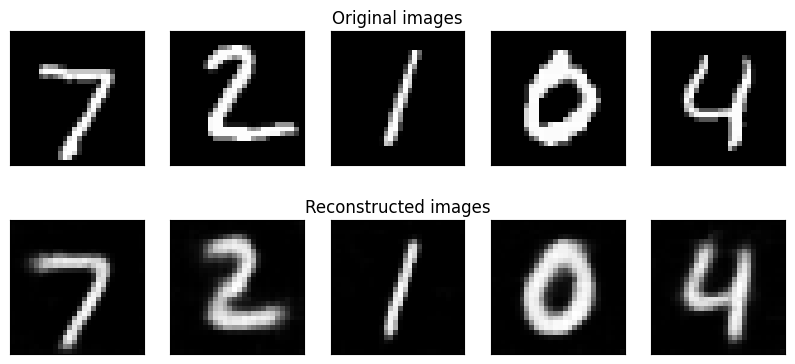


EPOCH 26/30 	 train loss 0.026 	 val loss 0.026


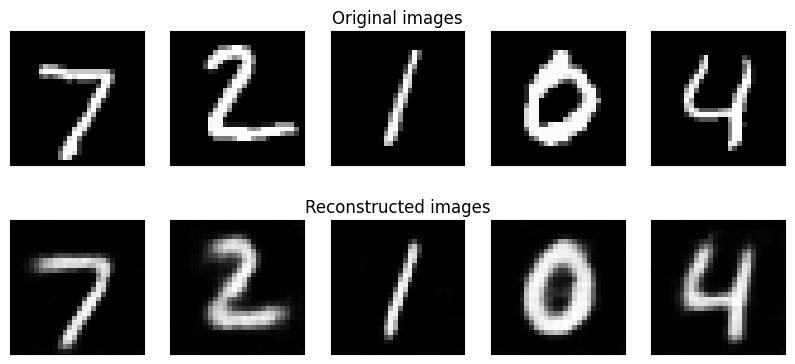


EPOCH 27/30 	 train loss 0.025 	 val loss 0.026


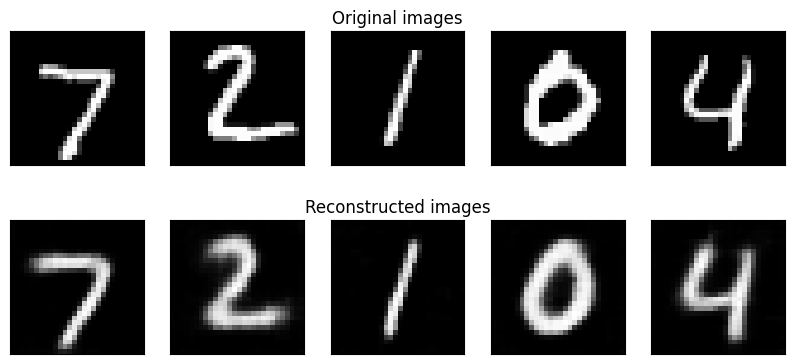


EPOCH 28/30 	 train loss 0.025 	 val loss 0.026


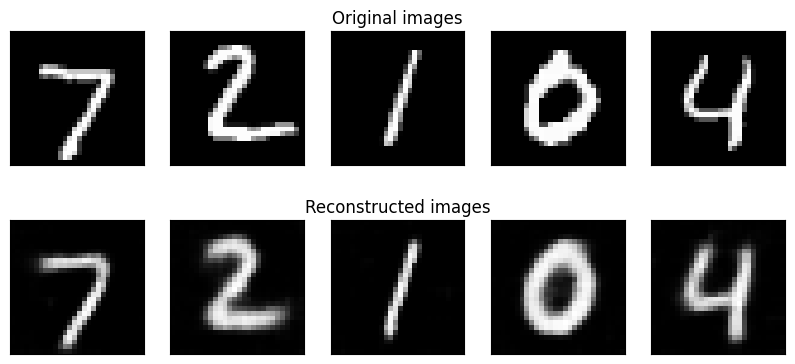


EPOCH 29/30 	 train loss 0.025 	 val loss 0.026


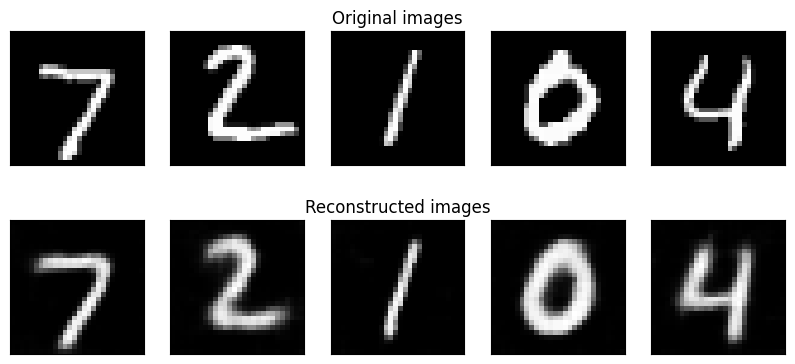


EPOCH 30/30 	 train loss 0.025 	 val loss 0.026


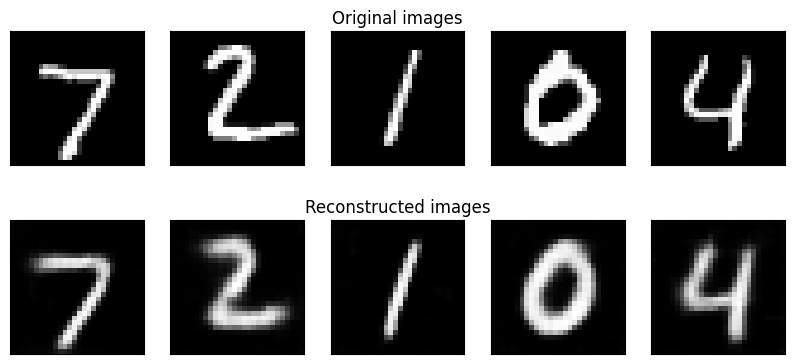

In [11]:
# Train the convolutional autoencoder.
num_epochs = 30
history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    train_loss = train_epoch(encoder, decoder, device, train_loader, loss_fn, optimizer)
    val_loss = test_epoch(encoder, decoder, device, valid_loader, loss_fn)

    print(f'\nEPOCH {epoch + 1}/{num_epochs} \t train loss {train_loss:.3f} \t val loss {val_loss:.3f}')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    plot_ae_outputs(encoder, decoder, n=5)


In [12]:
# Evaluate the final test loss.
print('Final test loss:', test_epoch(encoder, decoder, device, test_loader, loss_fn))


Final test loss: 0.025685271248221397


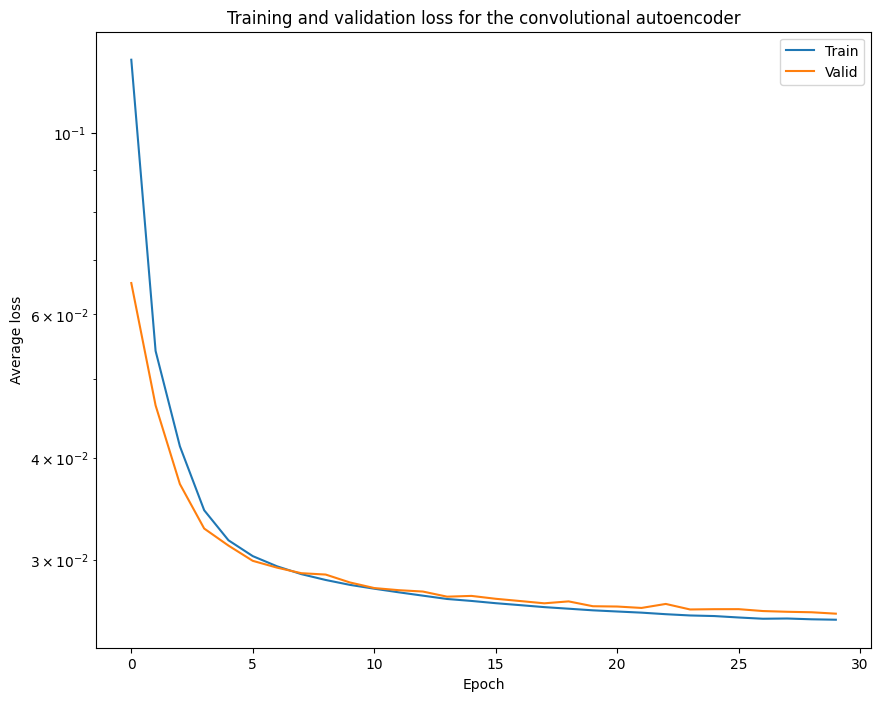

In [13]:
# Plot training and validation loss.
plt.figure(figsize=(10, 8))
plt.semilogy(history['train_loss'], label='Train')
plt.semilogy(history['val_loss'], label='Valid')
plt.xlabel('Epoch')
plt.ylabel('Average loss')
plt.legend()
plt.title('Training and validation loss for the convolutional autoencoder')
plt.show()


## Generate images from the latent space

The decoder can also be used on coordinates chosen directly in latent space.


In [14]:
def plot_reconstructed(decoder, r0=(-5, 10), r1=(-10, 5), n=10):
    plt.figure(figsize=(20, 8.5))
    w = 28
    img = np.zeros((n * w, n * w))
    with torch.no_grad():
        for i, y in enumerate(np.linspace(*r1, n)):
            for j, x in enumerate(np.linspace(*r0, n)):
                z = torch.tensor([[x, y, x, y]], dtype=torch.float32).to(device)
                x_hat = decoder(z)
                x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
                img[(n - 1 - i) * w:(n - i) * w, j * w:(j + 1) * w] = x_hat
    plt.imshow(img, extent=[*r0, *r1], cmap='gist_gray')
    plt.xlabel('Latent coordinate 1')
    plt.ylabel('Latent coordinate 2')
    plt.title('Images generated from points in latent space')


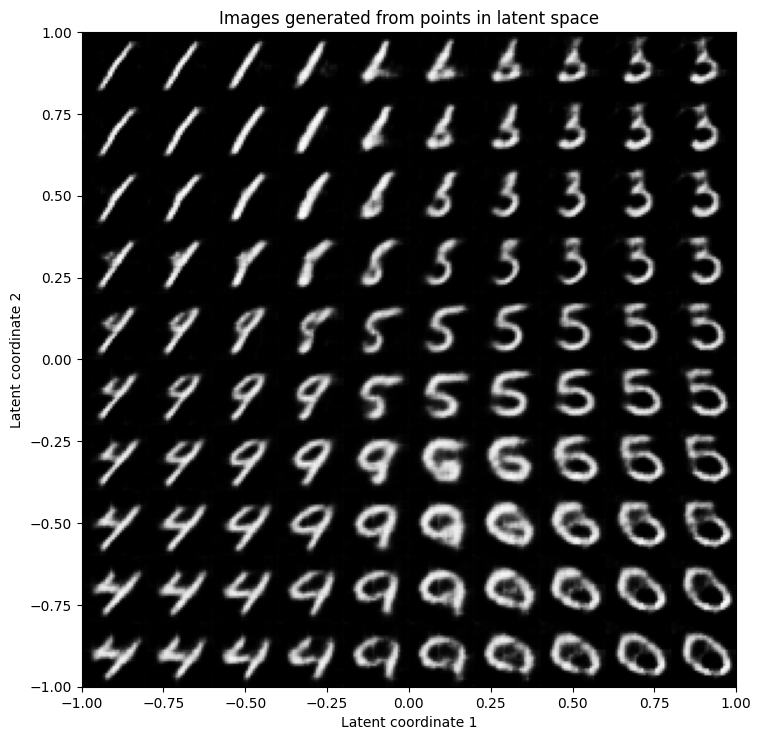

In [15]:
plot_reconstructed(decoder, r0=(-1, 1), r1=(-1, 1))


## Visualize the latent representation

We now encode the test dataset, store the latent coordinates, and look at them in scatter plots.


In [16]:
encoded_samples = []

encoder.eval()
for sample in tqdm(test_dataset):
    img = sample[0].unsqueeze(0).to(device)
    label = sample[1]
    with torch.no_grad():
        encoded_img = encoder(img)
    encoded_img = encoded_img.flatten().cpu().numpy()
    encoded_sample = {f'Enc. Variable {i}': enc for i, enc in enumerate(encoded_img)}
    encoded_sample['label'] = label
    encoded_samples.append(encoded_sample)


100%|██████████| 10000/10000 [00:11<00:00, 846.17it/s]


In [17]:
encoded_samples = pd.DataFrame(encoded_samples)
encoded_samples.head()


,Enc. Variable 0,Enc. Variable 1,Enc. Variable 2,Enc. Variable 3,label
0,-2.050204,0.312313,0.147247,-1.261214,7
1,-0.129552,0.815985,0.902922,0.351979,2
2,-0.559195,1.300640,-0.798994,0.075659,1
3,0.865073,-0.824055,0.244769,0.272170,0
4,0.082024,-0.406012,-0.709987,-1.041068,4


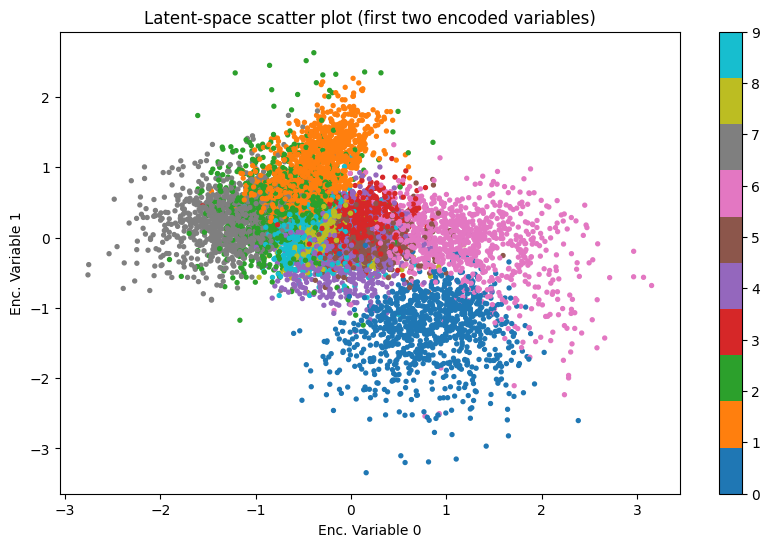

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(encoded_samples['Enc. Variable 0'], encoded_samples['Enc. Variable 1'], c=encoded_samples.label, cmap='tab10', s=8)
plt.colorbar()
plt.xlabel('Enc. Variable 0')
plt.ylabel('Enc. Variable 1')
plt.title('Latent-space scatter plot (first two encoded variables)')
plt.show()


In [19]:
# If the latent space has more than 2 dimensions, PCA can project it down to 2D.
pca = PCA(n_components=2)
components = pca.fit_transform(encoded_samples.drop(['label'], axis=1))
total_var = pca.explained_variance_ratio_.sum() * 100
print('Total variance explained by the first two PCA components:', total_var)


Total variance explained by the first two PCA components: 73.75509


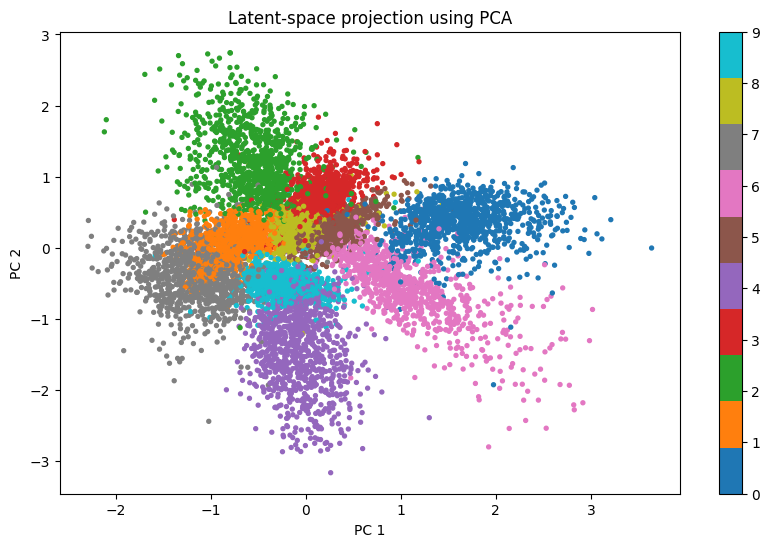

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], c=encoded_samples.label, cmap='tab10', s=8)
plt.colorbar()
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Latent-space projection using PCA')
plt.show()
